# Evalvaluate Predictions

In [1]:
%load_ext autoreload
%autoreload 2
import os
import polars as pl
import numpy as np
from deeptan.stat.metrics import MetricsDictMaker

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Computing metrics

In [2]:
path_home_deeptan = "/mnt/hdd2/homext/wuch/xn2p"
path_predictions = os.path.join(path_home_deeptan, "run", "predict")
path_raw_df = os.path.join(path_home_deeptan, "data", "raw_df")

### snRNA-seq

In [3]:
dataset = "sc_rna_annotated_minmi0.0_top2000"
path_true = os.path.join(path_raw_df, "scRNA", "GSE226097_Annotated_split_strata")
path_orig_h5ad = os.path.join(path_true, "origin.h5ad")

metricsmaker_snrna = MetricsDictMaker(os.path.join(path_predictions, dataset), path_true, True, path_orig_h5ad)
metricsmaker_snrna.run()


Computing metrics for recon...
Computing metrics for label...
Calculating cluster metrics...



/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not de

### Save to CSV

In [4]:
metricsmaker_snrna.metrics_dict["summary_recon"].write_csv(f"result.{dataset}.summary_recon.csv")
metricsmaker_snrna.metrics_dict["summary_label"].write_csv(f"result.{dataset}.summary_label.csv")
metricsmaker_snrna.metrics_dict["summary_clustering"].write_csv(f"result.{dataset}.summary_clustering.csv")

## Plot

In [5]:
from deeptan.stat.plots import kde_grid_plot, kde_grid_plot_data, metrics_plot, metrics_plot_data, pacmap_plot, pacmap_plot_data

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

### Plot recon distribution

In [6]:
_dim = "sample_metrics"
# dim = "feature_metrics"

_metrics = ["mse", "mae", "jsd", "pcc"]
_metrics_text = ["MSE", "MAE", "JSD", "PCC"]

x_lab = "multitask"
x_lab_text = "Multitask"

y_labs = ["multitask_noguide", "focus_recon", "focus_label_on_focus_recon", "focus_label"]
y_labs_text = ["Multitask (no SGG)", "Focus on reconstruction", "Fine-tuned on reconstruction", "Focus on labelling"]
# y_labs = ["focus_recon", "focus_label_on_focus_recon", "focus_label"]
# y_labs_text = ["Focus on reconstruction", "Fine-tuned on reconstruction", "Focus on labelling"]

_tasks = [x_lab] + y_labs

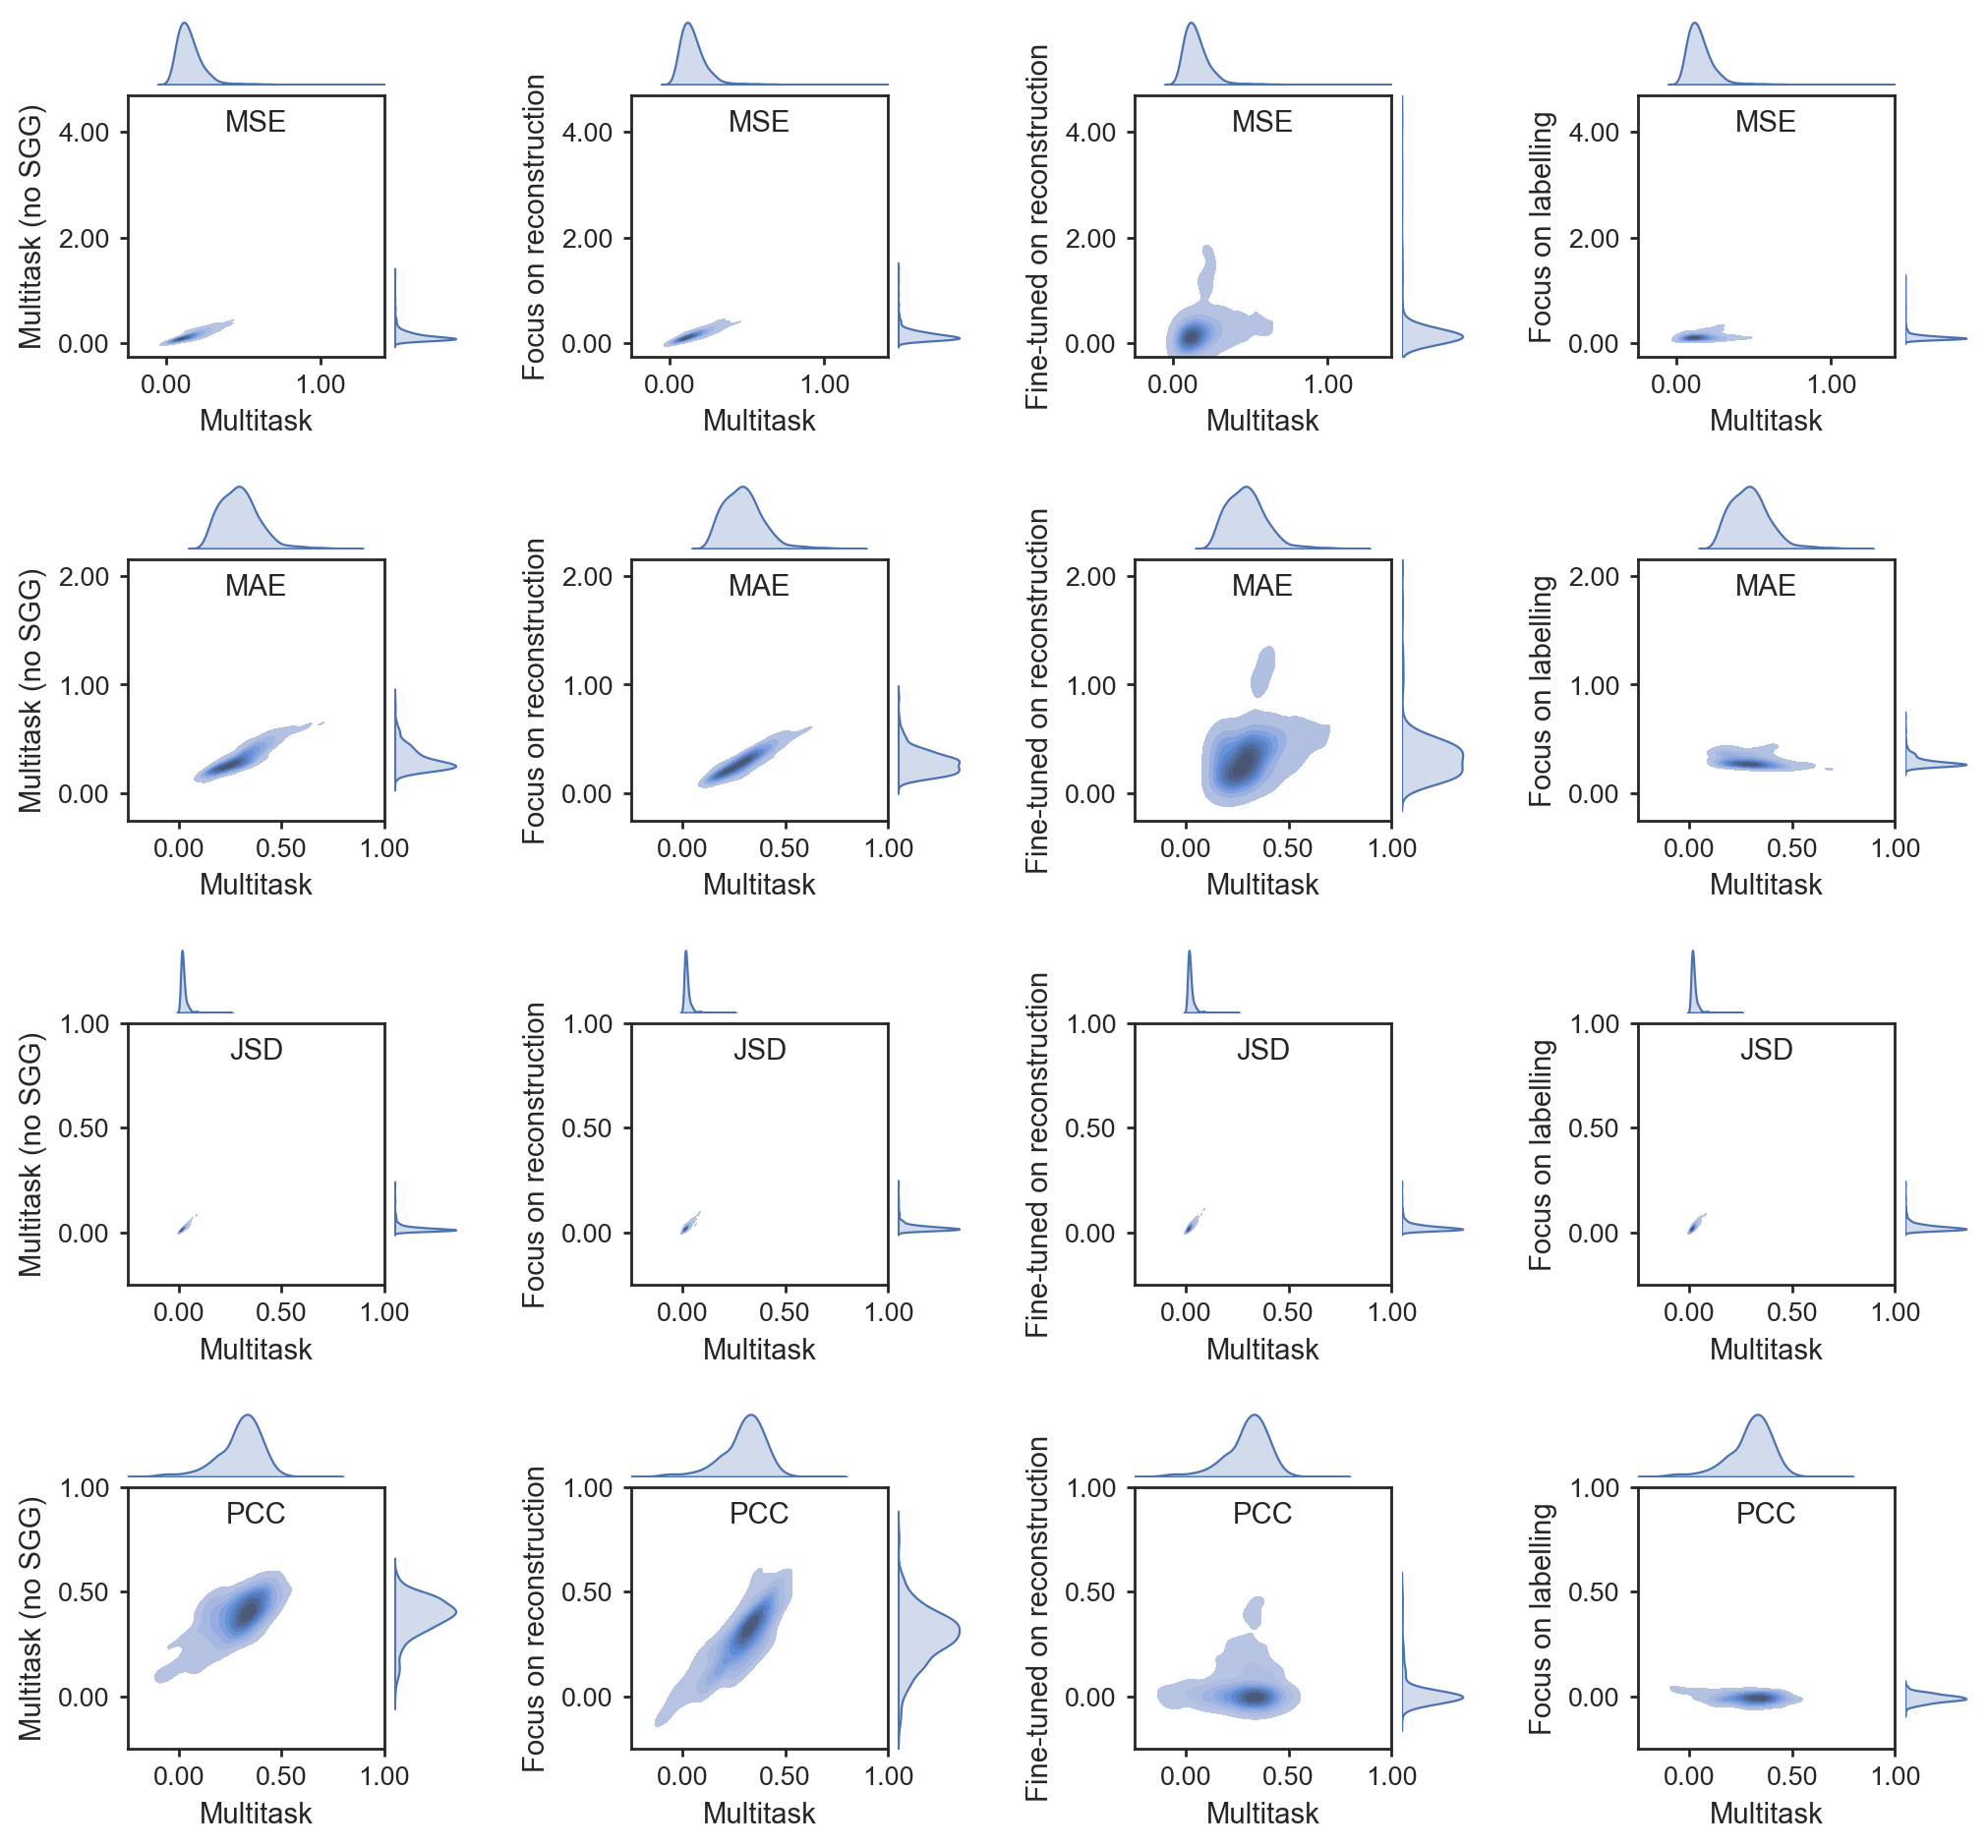

In [7]:
_tmp_dataset = metricsmaker_snrna
_split = "tst"
fig_name = f"fig.c2.snrna.{_split}.recon_sgg.dist"
# fig_name = f"fig.c2.snrna.{_split}.recon.dist"

data4kde = kde_grid_plot_data(_tmp_dataset, 42, _metrics, _tasks, _dim)
_fig = kde_grid_plot(data4kde, x_lab, y_labs, _metrics, _metrics_text, x_lab_text, y_labs_text, _dim, fig_name, ".fig/", _split)

### Plot all metrics

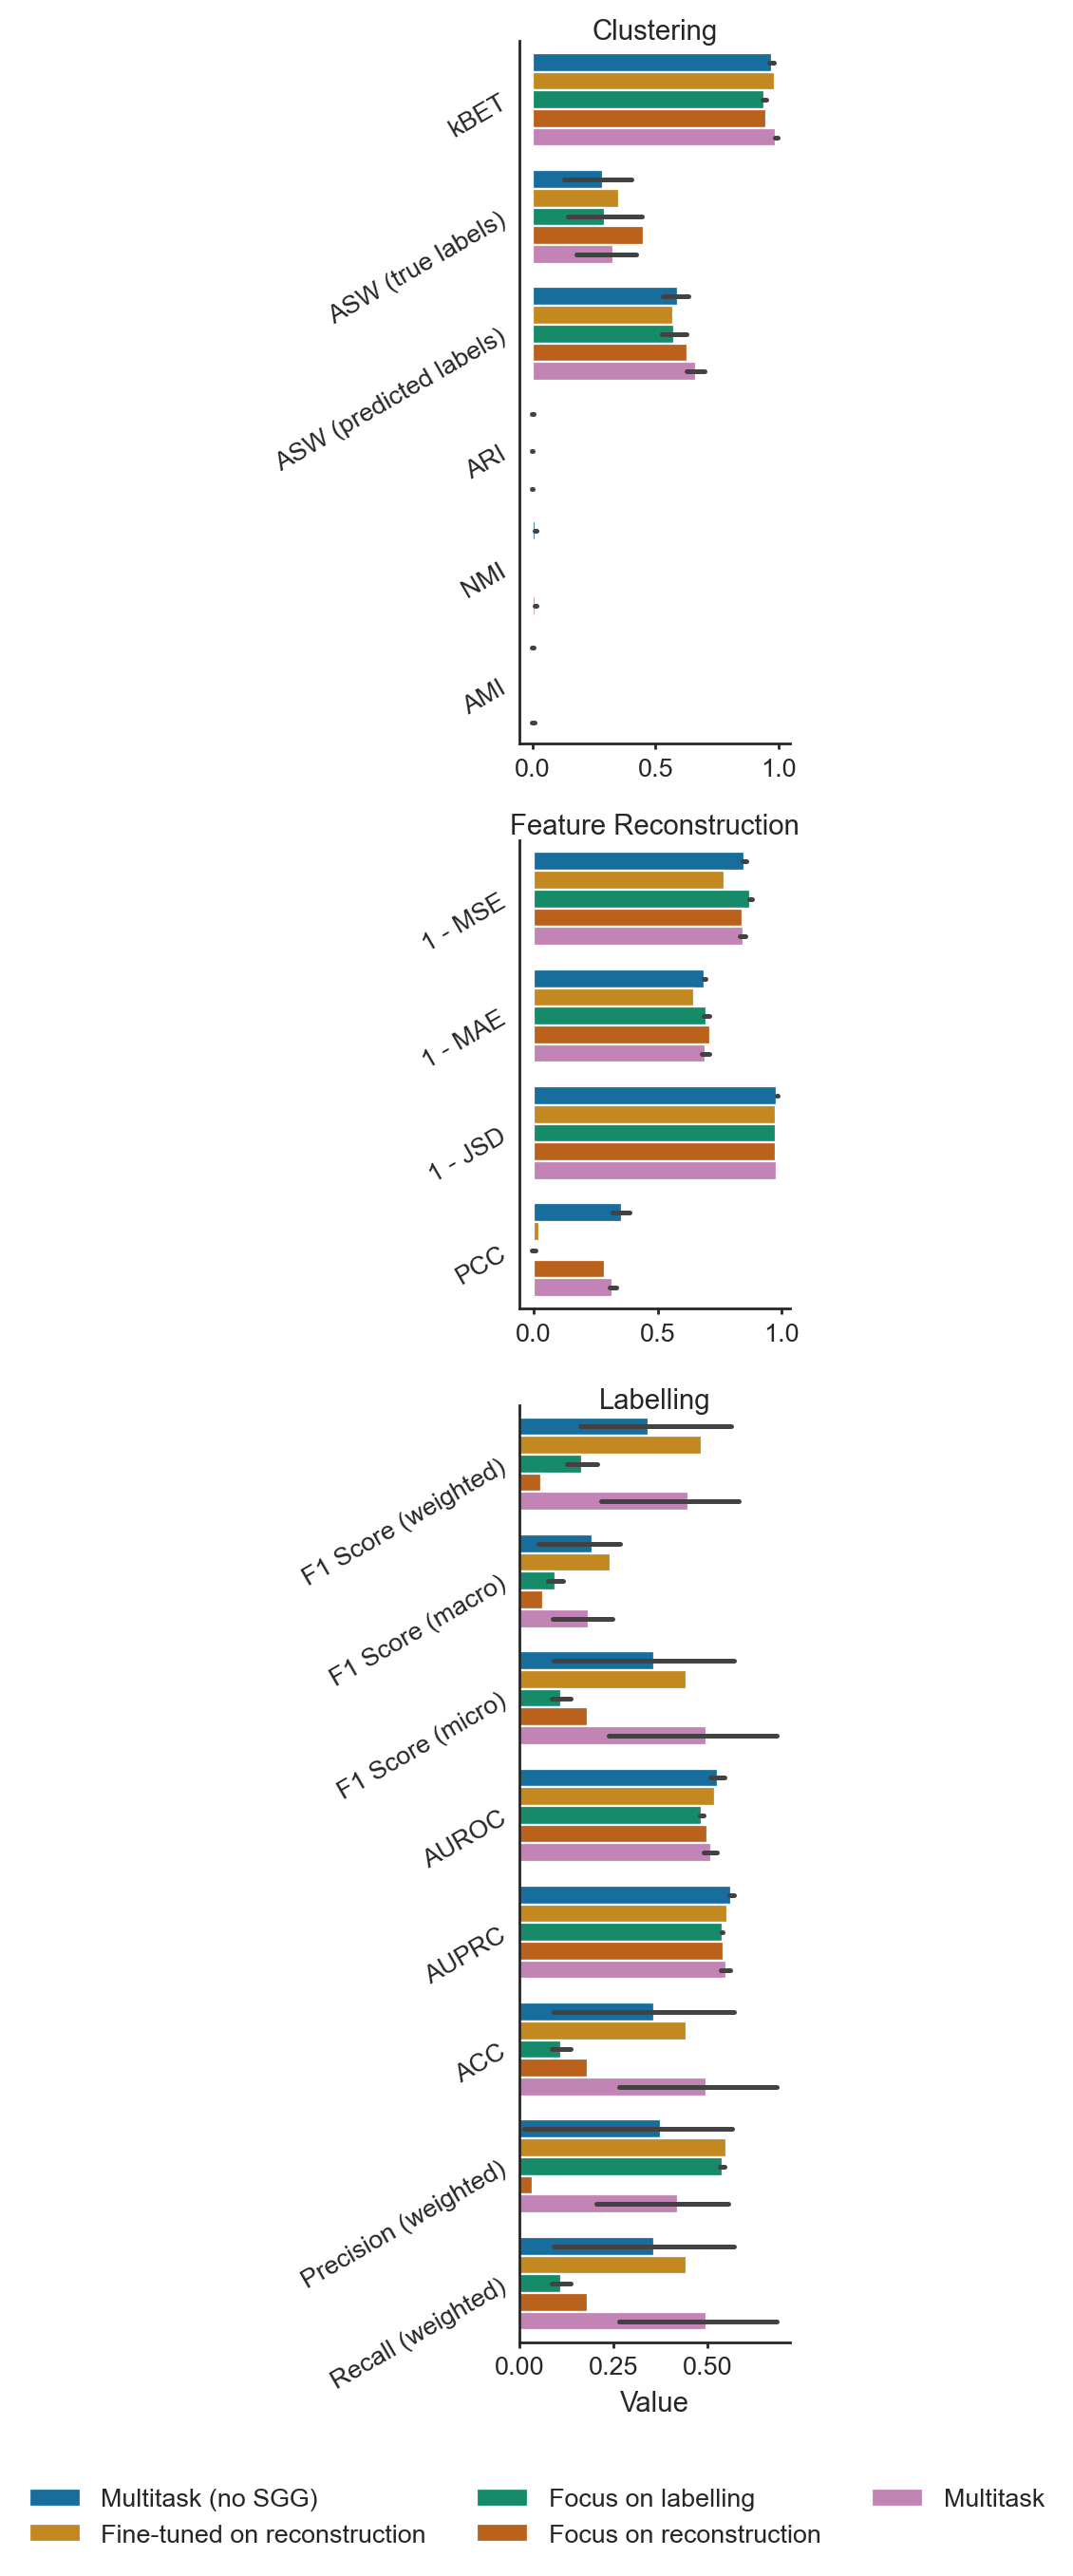

In [8]:
_tmp_dataset = metricsmaker_snrna
_split = "tst"
fig_name = f"fig.c2.snrna.{_split}.metrics_sgg"
# fig_name = f"fig.c2.snrna.{_split}.metrics"

_df_plot_allmetrics = metrics_plot_data(_tmp_dataset, _split)
_df_plot_allmetrics = _df_plot_allmetrics.filter(~pl.col("Metric").is_in(["Spearman", "AMI (Leiden)", "NMI (Leiden)", "ARI (Leiden)"]))
# _df_plot_allmetrics = _df_plot_allmetrics.filter(pl.col("Task") != "Multitask (no SGG)").filter(pl.col("Metric") != "Spearman")
_fig = metrics_plot(_df_plot_allmetrics, fig_name, ".fig/")

### Plot PaCMAP

In [9]:
_tmp_dataset = metricsmaker_snrna
_seed = 42
_split = "tst"
fig_name = f"fig.c2.snrna.{_split}.cell_emb_sgg"
# fig_name = f"fig.c2.snrna.{_split}.cell_emb"

x_lab = "multitask"
x_lab_text = "Multitask"

y_labs = ["multitask_noguide", "focus_recon", "focus_label_on_focus_recon", "focus_label"]
y_labs_text = ["Multitask (no SGG)", "Focus on reconstruction", "Fine-tuned on reconstruction", "Focus on labelling"]
# y_labs = ["focus_recon", "focus_label_on_focus_recon", "focus_label"]
# y_labs_text = ["Focus on reconstruction", "Fine-tuned on reconstruction", "Focus on labelling"]

_tasks = [x_lab] + y_labs
_tasks_text = [x_lab_text] + y_labs_text

In [10]:
cell_embs_pacmap, y_true_text, ys_pred_text = pacmap_plot_data(_tmp_dataset, _tasks, _split, _seed)

Unique cell types:  ['Epidermal', 'Guard', 'Pollen', 'Stele', 'unknown']
Task multitask: (679, 2)
Task multitask_noguide: (679, 2)
Task focus_recon: (679, 2)
Task focus_label_on_focus_recon: (679, 2)
Task focus_label: (679, 2)


#### Now we can plot

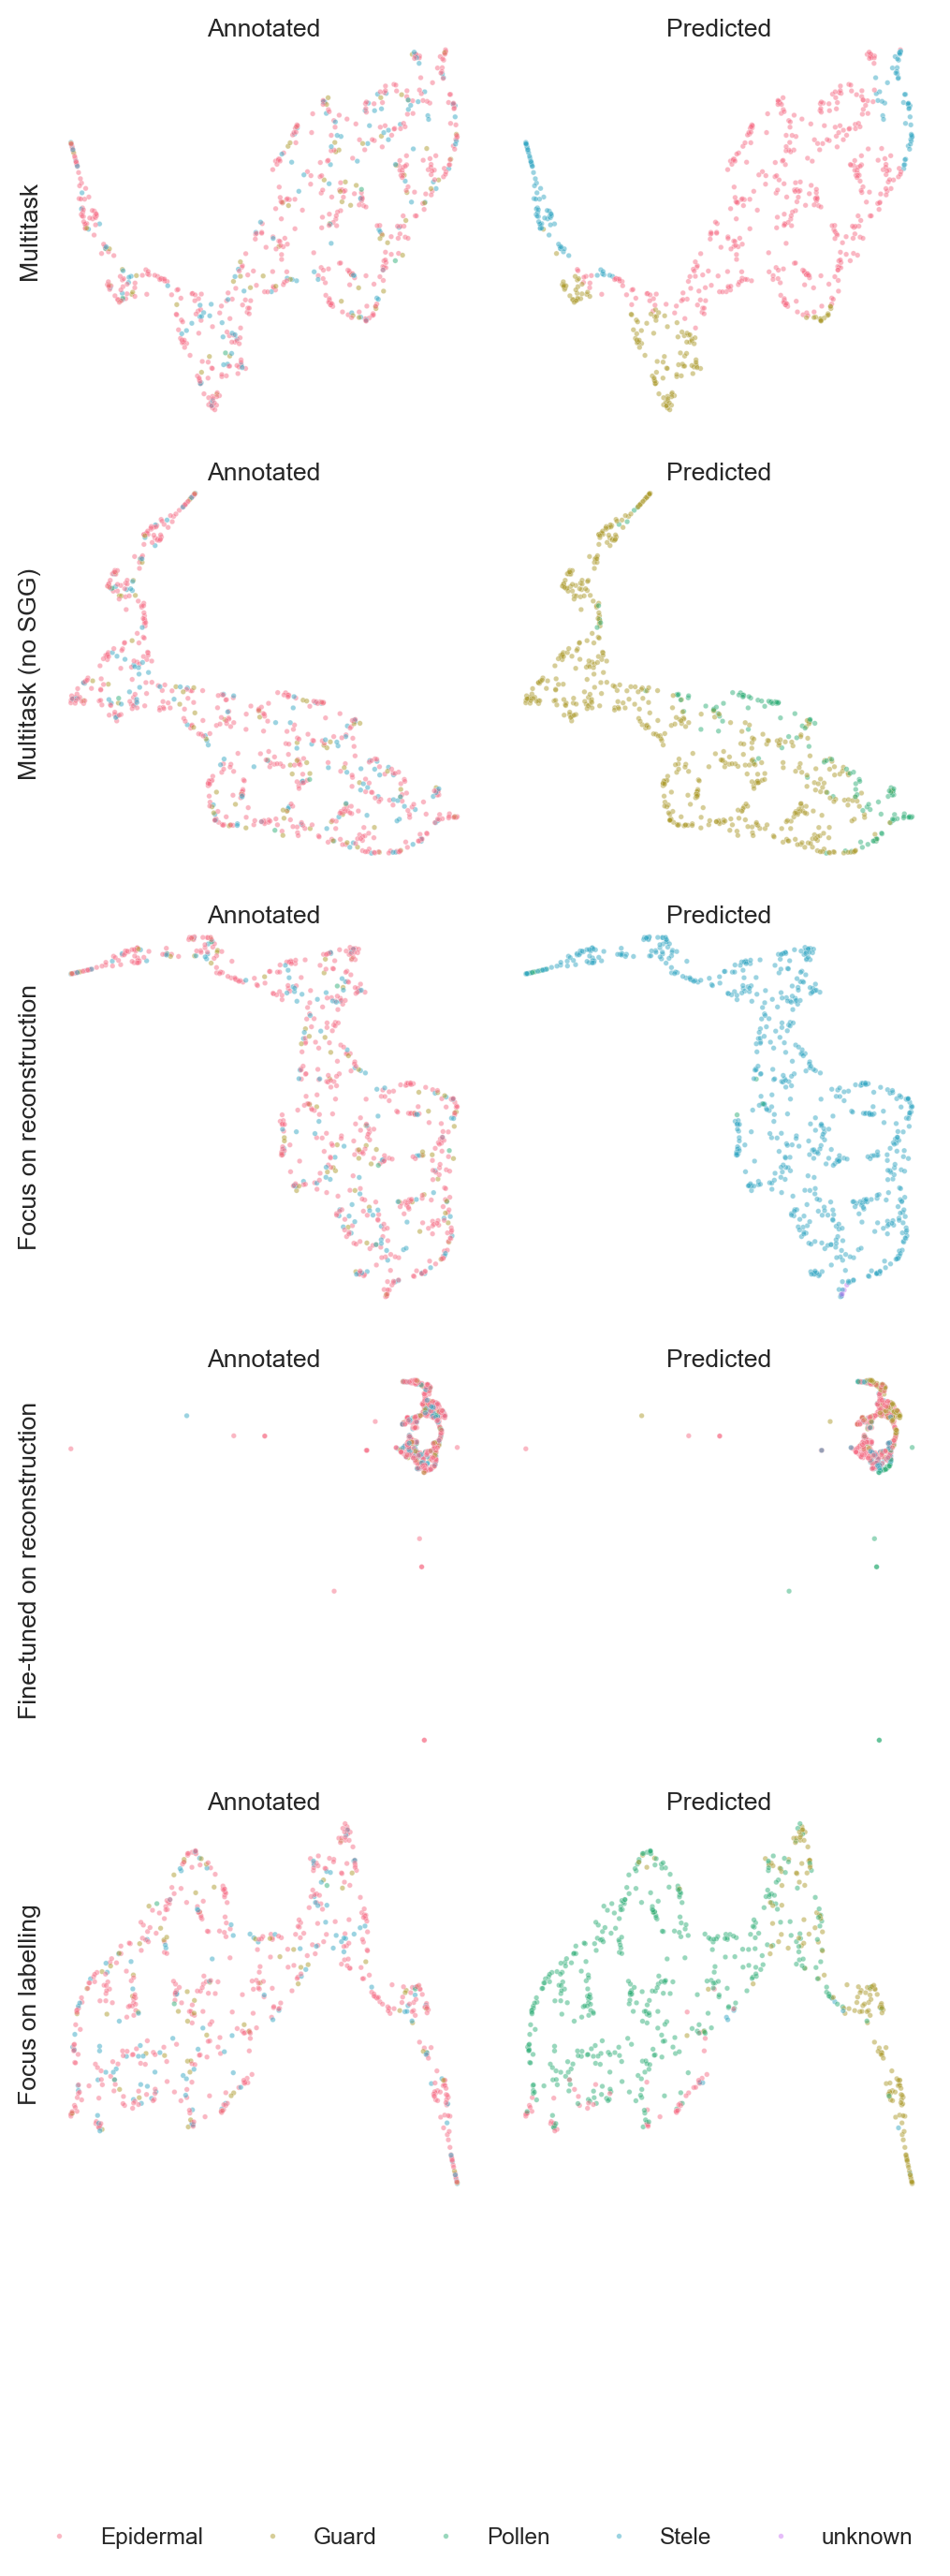

In [11]:
_fig = pacmap_plot(cell_embs_pacmap, _tasks_text, y_true_text, ys_pred_text, fig_name, ".fig/")

### Plot feature embeddings

In [56]:
_tmp_dataset = metricsmaker_snrna
_seed = 42
_split = "tst"
fig_name = f"fig.c2.snrna.{_split}.feature_emb"

In [ ]:
# Get feature names
_feat_names = _tmp_dataset.metrics_dict["true"][f"seed_{_seed}_{_split}"]["feature_names"]
_modality = ["Peak" for i in _feat_names if ":" in i else "RNA"]

In [57]:
x_lab = "multitask"
x_lab_text = "Multitask"

y_labs = ["multitask_noguide", "focus_recon", "focus_label_on_focus_recon", "focus_label"]
y_labs_text = ["Multitask (no SGG)", "Focus on reconstruction", "Fine-tuned on reconstruction", "Focus on labelling"]
# y_labs = ["focus_recon", "focus_label_on_focus_recon", "focus_label"]
# y_labs_text = ["Focus on reconstruction", "Fine-tuned on reconstruction", "Focus on labelling"]

_tasks = [x_lab] + y_labs
_tasks_text = [x_lab_text] + y_labs_text

In [58]:
feat_embs = {}
_fnames = []
for _task in _tasks:
    _fname = _tmp_dataset.ident.filter((pl.col("task") == _task) & (pl.col("seed_num") == _seed) & (pl.col("split") == _split))["fname"].item()
    _fnames.append(_fname)
    feat_embs[_task] = _tmp_dataset.metrics_dict["prediction"][_fname]["node_recon"]

In [ ]:
print(feat_embs.keys())

In [66]:
print(feat_embs["multitask"].shape)

(679, 2000, 256)


In [ ]:
import pacmap

embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.3, FP_ratio=4.0)

# # fit the data (The index of transformed data corresponds to the index of the original data)
# X_transformed = embedding.fit_transform(X, init="pca")

feat_embs_pacmap = {}
samples = [0,1,2,3]
for _s in samples:
    feat_embs_pacmap[_s] = {}
    for _task in feat_embs.keys():
        feat_embs_pacmap[_s][_task] = embedding.fit_transform(feat_embs[_task][_s], init="pca")
        print(f"Sample {_s} Task {_task}: {feat_embs_pacmap[_s][_task].shape}")

#### Plot 4 samples feature emb

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

In [ ]:
try:
    plt.clf()
except:
    pass

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
# a4_width_cm = 21
# cm_to_inches = 0.393701
# a4_width_inches = a4_width_cm * cm_to_inches
n_cols = len(feat_embs_pacmap) # Samples
n_rows = len(feat_embs_pacmap[0]) # Tasks

fig_width = 2.6 * n_cols  # 调整图表的整体宽度以适应列数
fig_height = 2.4 * n_rows  # 调整图表的整体高度以适应行数

sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.0)  # 设置图表的上下文和字体大小

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=False,  # 不共享 x 轴
    sharey=False,  # 不共享 y 轴
)
if n_rows == 1:
    axes = axes.reshape(1, -1)

for _s in samples:
    for i, _task in enumerate(y_labs):
        ax = axes[_s, i]
        if i == 0:
            ax.set_ylabel(f"Data point {_s+1}")
        if _s == 0:
            ax.set_title(y_labs_text[i])
        sns.scatterplot(x=feat_embs_pacmap[_s][_task][:, 0], y=feat_embs_pacmap[_s][_task][:, 1], alpha=0.5, hue=_modality, s=4, ax=ax, legend=False)
        # 删除框线
        for spine in ax.spines.values():
            spine.set_visible(False)
        # 删除刻度棒和刻度数字
        ax.tick_params(axis='both', which='both', length=0)  # 隐藏刻度棒
        ax.set_xticks([])  # 清空 x 轴刻度
        ax.set_yticks([])  # 清空 y 轴刻度

fig.tight_layout(pad=1.2)
fig.show()

# Save as PNG and PDF
fig.savefig(f".fig/{fig_name}.png", dpi=300)
fig.savefig(f".fig/{fig_name}.pdf")